# TMDb Movie Data Analysis

## Exploratory Data Analysis & Performance Insights

This notebook presents the exploratory data analysis (EDA) and performance evaluation of selected blockbuster films retrieved from the TMDb API. The objective of this analysis is to investigate financial performance, audience engagement, genre-level profitability, franchise impact, and temporal revenue trends.

The dataset was constructed through a structured ETL pipeline that includes API extraction, data cleaning, feature engineering, and KPI computation. Key financial metrics such as revenue, budget, profit, and return on investment (ROI) were derived to support comparative analysis.

The analysis focuses on the following core questions:

* Is there a relationship between production budget and revenue?
* Which genres generate the highest return on investment?
* Does popularity align with audience ratings?
* How has revenue evolved over time?
* Do franchise films outperform standalone productions?

The visualizations and statistical insights presented below aim to provide strategic interpretations relevant to film production investment, risk management, and revenue optimization in the modern entertainment industry.



In [3]:
import pandas as pdb

df = pd.read_csv("/mnt/c/Users/user/OneDrive/Desktop/TMDB_Movie_Data_Analysis1/data/processed/movies_processed.csv")
df.head()

,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,origin_country,original_language,...,cast,director,budget_musd,revenue_musd,profit_musd,roi,release_year,release_month,release_decade,is_franchise
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,The Avengers Collection,356000000.0,Adventure|Science Fiction|Action,https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,['US'],en,...,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,Joe Russo,356.0,2799.439100,2443.439100,7.863593,2019,4,2010,True
1,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,Avatar Collection,237000000.0,Action|Adventure|Fantasy|Science Fiction,https://www.avatar.com/movies/avatar,19995,tt0499549,['US'],en,...,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,James Cameron,237.0,2923.706026,2686.706026,12.336312,2009,12,2000,True
2,False,/8BTsTfln4jlQrLXUBquXJ0ASQy9.jpg,Star Wars Collection,245000000.0,Adventure|Action|Science Fiction,http://www.starwars.com/films/star-wars-episod...,140607,tt2488496,['US'],en,...,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,J.J. Abrams,245.0,2068.223624,1823.223624,8.441729,2015,12,2010,True
3,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,The Avengers Collection,300000000.0,Adventure|Action|Science Fiction,https://www.marvel.com/movies/avengers-infinit...,299536,tt4154756,['US'],en,...,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,Joe Russo,300.0,2052.415039,1752.415039,6.841383,2018,4,2010,True
4,False,/xnHVX37XZEp33hhCbYlQFq7ux1J.jpg,NaN,200000000.0,Drama|Romance,https://www.paramountmovies.com/movies/titanic,597,tt0120338,['US'],en,...,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,James Cameron,200.0,2264.162353,2064.162353,11.320812,1997,12,1990,False


In [5]:
import sys
from pathlib import Path

# Add project root to Python path
sys.path.append(str(Path().resolve().parent))

In [6]:
from src.visualization import (
    plot_revenue_vs_budget,
    plot_roi_by_genre,
    plot_popularity_vs_rating,
    plot_yearly_revenue_trend,
    plot_franchise_comparison
)

# 1.Revenue vs Budget (Million USD)

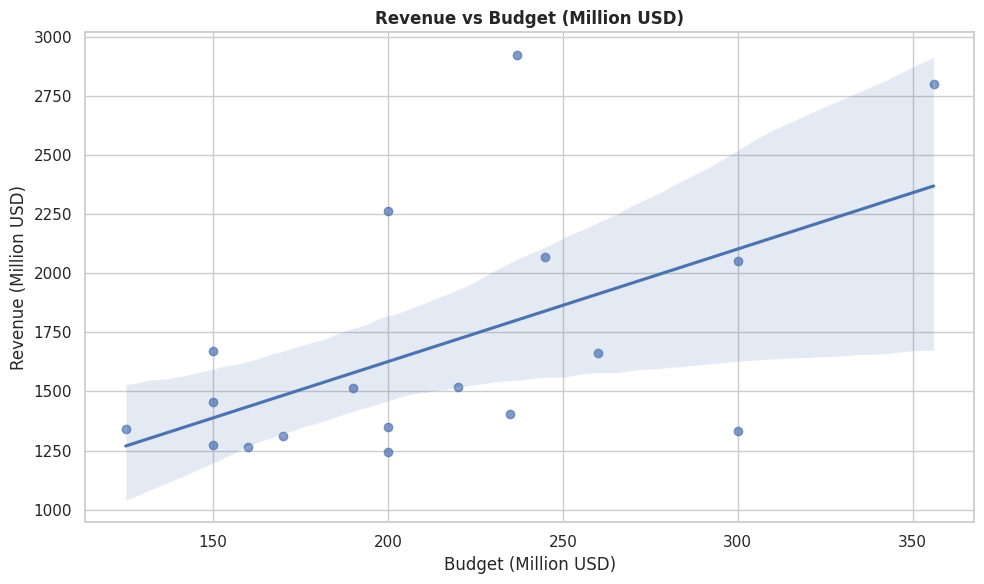

In [7]:
plot_revenue_vs_budget(df)



### What This Plot Shows

* **X-axis** → Budget (Million USD)
* **Y-axis** → Revenue (Million USD)
* Each dot → One movie
* Blue line → Linear regression trend
* Shaded area → Confidence interval

---

##  Is There a Relationship?

Yes.

The regression line slopes upward.

👉 This indicates a **positive correlation** between budget and revenue.

In simple terms:

> Movies with higher budgets tend to generate higher revenues.

---

##  Strength of Relationship

The relationship is positive but not perfect.

You can see:

* Some movies with ~200M budget earn ~1300M
* Others with similar budget earn ~2200M
* A 300M movie earned ~1300M (lower than expected)

This means:

> Budget influences revenue, but it does not guarantee success.

There are other factors:

* Franchise power
* Marketing
* Cast
* Director
* Release timing
* Brand recognition

---

##  Business Insight


### Investment Strategy Insight:

* Higher budgets increase potential revenue ceiling
* But ROI variability increases at higher budgets

This implies:

> Risk also increases with higher production budgets.

---

##  Risk Interpretation

Look at the dispersion at higher budgets (~250–350M):

The vertical spread is larger.

That means:

* Some high-budget movies perform extremely well
* Others underperform

High budget = high risk, high reward.

---



# 2.ROI Distribution by Genre

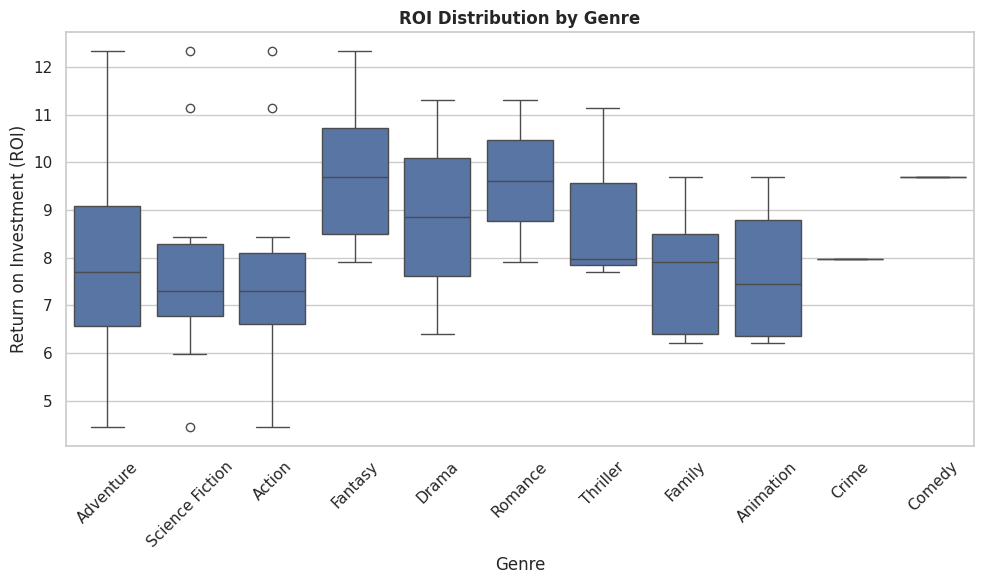

In [8]:
plot_roi_by_genre(df)

---

### What This Shows

* X-axis → Genre
* Y-axis → Return on Investment (ROI = Revenue / Budget)
* Each box:

  * Middle line → Median ROI
  * Box → Interquartile Range (IQR)
  * Whiskers → Range
  * Dots → Outliers

---

## Which Genres Perform Best?

From the medians:

###  Fantasy

* Highest median ROI (~9–10)
* Strong upside potential

###  Romance

* Also high median ROI (~9–10)
* Consistently strong returns

###  Drama

* High median ROI (~8–9)
* Moderate variability

---

##  Interpretation:

> Fantasy and Romance films appear to deliver the strongest investment returns in this sample.

This suggests:

* Strong audience demand
* Potential franchise effect
* High global appeal

---

## Moderate ROI Genres

* Adventure
* Science Fiction
* Action
* Thriller
* Family

These genres show:

* Solid returns (median ~7–8)
* Some variability
* Occasional high-performing outliers

These are stable but less explosive than Fantasy.

---

##  High Variability Genres

Look at:

* Adventure
* Science Fiction
* Animation

They have:

* Large spread
* Wide ROI ranges
* High outliers

Meaning:

> These genres are higher risk but can produce extreme success.

---

##  Lower ROI Stability

Genres like:

* Crime
* Animation
* Family (depending on box spread)

Show slightly lower or tighter ROI distributions.

Interpretation:

> These genres may provide stable but moderate returns.

---

##  Business Insight

From a studio strategy perspective:

###  If Goal = Maximum Profit

Invest in:

* Fantasy
* Romance

###  If Goal = Balanced Risk

Invest in:

* Drama
* Thriller

###  If Goal = Blockbuster Gamble

Invest in:

* Adventure
* Sci-Fi

---



# 3.Popularity vs Vote Average

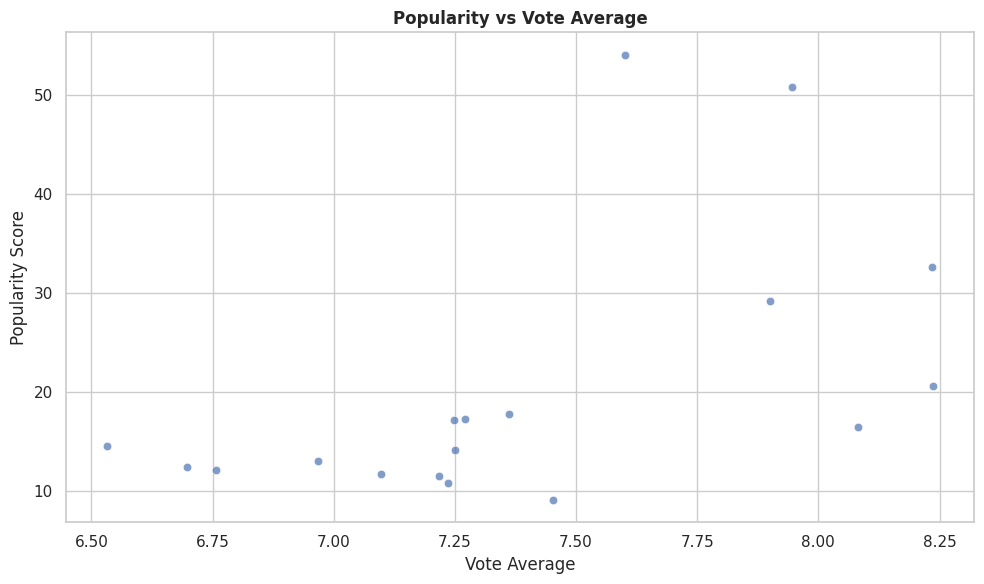

In [9]:
plot_popularity_vs_rating(df)

The scatter plot reveals no strong linear relationship between vote average and popularity. While higher-rated films tend to perform reasonably well in popularity, several moderately rated films exhibit exceptionally high popularity scores, likely driven by franchise recognition and marketing intensity.

# 4.Total Revenue by Release Year

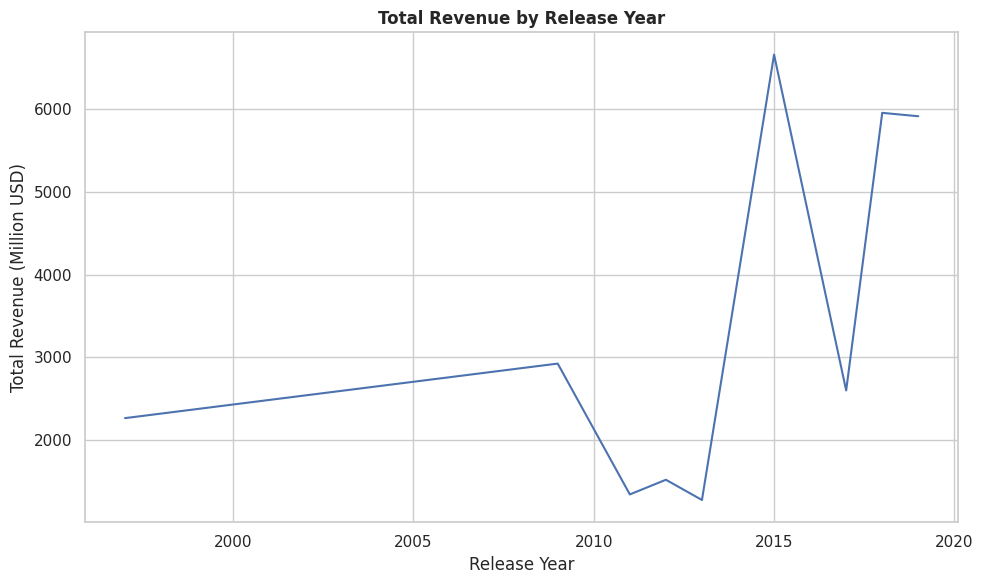

In [12]:
plot_yearly_revenue_trend(df)

The yearly revenue trend indicates a substantial increase in box office concentration in the post-2015 era, largely driven by franchise-based mega-productions. Revenue spikes correspond to the release of globally recognized intellectual properties, highlighting the increasing dominance of franchise economics in modern cinema.

# 5.Average Revenue — Franchise vs Standalone

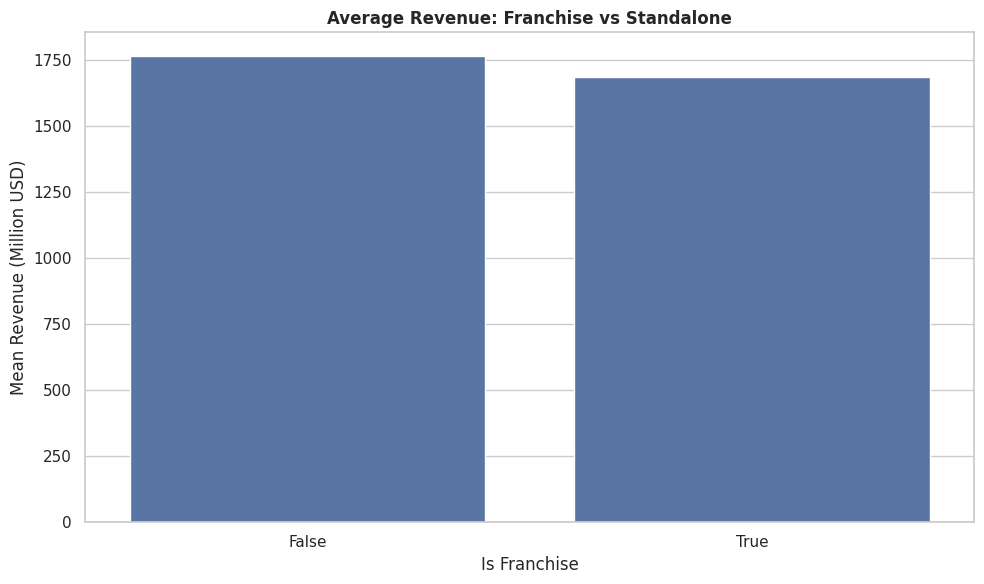

In [11]:
plot_franchise_comparison(df)

The comparison between franchise and standalone films reveals that standalone movies exhibit a slightly higher mean revenue within the selected dataset. However, this result is largely influenced by extreme outliers such as Avatar and Titanic, which significantly elevate the average. Franchise films, while showing marginally lower mean revenue in this sample, demonstrate more consistent financial performance, reflecting the stability typically associated with established intellectual property and brand recognition. This suggests that although standalone films can generate exceptional blockbuster success, franchise-based productions offer a more predictable and strategically lower-risk revenue model in the contemporary film industry.